In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from lightgbm import LGBMClassifier

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load data
train_path = "data/train.csv"
test_path = "data/test.csv"
sample_sub_path = "data/sample_submission.csv"

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)
sample_sub = pd.read_csv(sample_sub_path)

In [3]:
target_col = "diagnosed_diabetes"

In [4]:
# Split features and target
X = train_df.drop(columns=[target_col])
y = train_df[target_col]
X_test = test_df.copy()

In [5]:
X["id_bin"] = pd.qcut(X["id"], q=20, labels=False)
X_test["id_bin"] = pd.qcut(X_test["id"], q=20, labels=False)

In [6]:
# Detect numeric and categorical columns
num_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

In [7]:
X = X[num_cols + cat_cols]
X_test = X_test[num_cols + cat_cols]

print("Numeric columns:", num_cols)
print("Categorical columns:", cat_cols)

Numeric columns: ['id', 'age', 'alcohol_consumption_per_week', 'physical_activity_minutes_per_week', 'diet_score', 'sleep_hours_per_day', 'screen_time_hours_per_day', 'bmi', 'waist_to_hip_ratio', 'systolic_bp', 'diastolic_bp', 'heart_rate', 'cholesterol_total', 'hdl_cholesterol', 'ldl_cholesterol', 'triglycerides', 'family_history_diabetes', 'hypertension_history', 'cardiovascular_history', 'id_bin']
Categorical columns: ['gender', 'ethnicity', 'education_level', 'income_level', 'smoking_status', 'employment_status']


In [8]:
# Preprocessing
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_cols),
        ("cat", categorical_transformer, cat_cols)
    ]
)

In [9]:
# LightGBM baseline model
lgbm_model = LGBMClassifier(
    objective="binary",
    boosting_type="gbdt",
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=31,
    max_depth=-1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    verbosity=-1
)

lgbm_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", lgbm_model)
])

In [10]:
# Cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(
    lgbm_pipeline,
    X,
    y,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1
)

print("Fold AUC scores:", cv_scores)
print("Mean CV AUC:", cv_scores.mean())
print("Std CV AUC:", cv_scores.std())

/Users/heosunghak/miniforge3/envs/titanic/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/heosunghak/miniforge3/envs/titanic/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/heosunghak/miniforge3/envs/titanic/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/heosunghak/miniforge3/envs/titanic/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/heosunghak/miniforge3/envs/titanic/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning

Fold AUC scores: [0.72515278 0.72298901 0.72387325 0.72474619 0.72424503]
Mean CV AUC: 0.7242012537582532
Std CV AUC: 0.0007458425539211293


In [11]:
# Train on full training data
lgbm_pipeline.fit(X, y)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [12]:
# Predict on test data
test_pred_proba = lgbm_pipeline.predict_proba(X_test)[:, 1]

# Create submission
submission = sample_sub.copy()
submission.iloc[:, 1] = test_pred_proba

submission.to_csv("submissions/lightgbm_with_id_engineered.csv", index=False)
print("Saved: submissions/lightgbm_with_id_engineered.csv")

/Users/heosunghak/miniforge3/envs/titanic/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/var/folders/m_/gq3fgb6x2rs_xpbs_2llxbvc0000gn/T/ipykernel_24726/3782153643.py:6: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0.51874853 0.67545018 0.76513567 ... 0.53546389 0.61311882 0.59471399]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  submission.iloc[:, 1] = test_pred_proba


Saved: submissions/lightgbm_with_id_engineered.csv


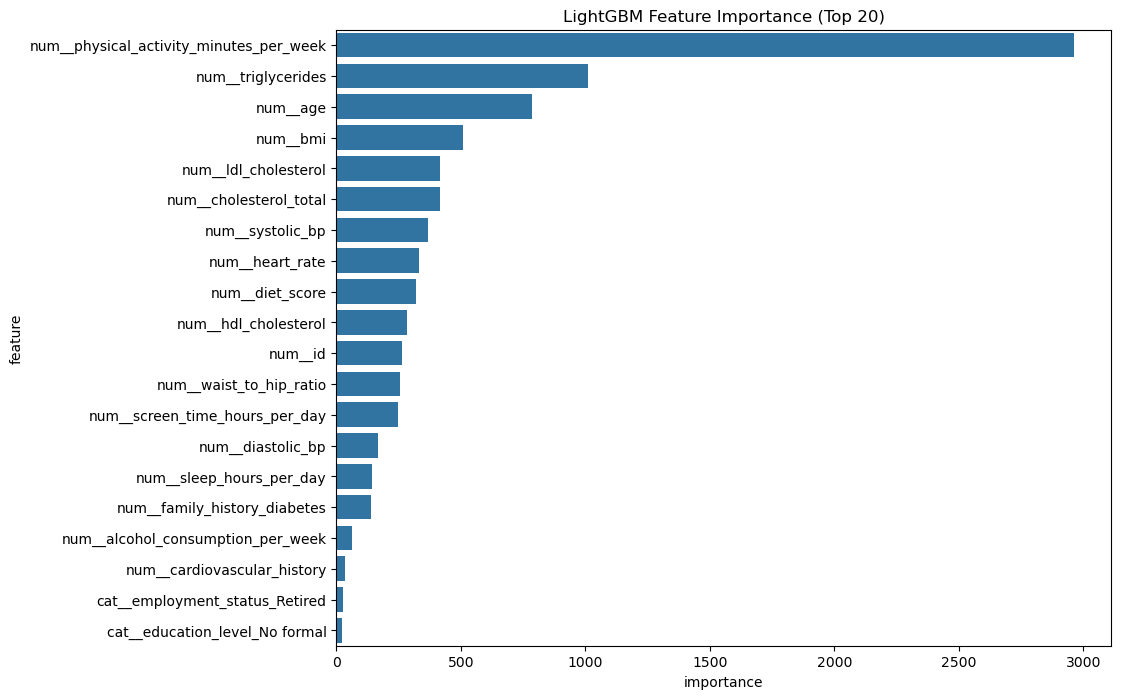

Importance of ID Feature:
                           feature  importance
15              num__triglycerides        1011
0                          num__id         265
19                     num__id_bin          20
35        cat__income_level_Middle          19
36  cat__income_level_Upper-Middle           9
34  cat__income_level_Lower-Middle           5


In [13]:
feature_names = preprocessor.get_feature_names_out()

importances = lgbm_model.feature_importances_

feature_importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values(by='importance', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x='importance', y='feature', data=feature_importance_df.head(20))
plt.title('LightGBM Feature Importance (Top 20)')
plt.show()

id_rank = feature_importance_df[feature_importance_df['feature'].str.contains('id')]
print("Importance of ID Feature:")
print(id_rank)
